# Assumptions on $\gamma$

Every assumption of the paper that bears on the asymptotic dissimilarities
$\Gamma_{k\ell} = \gamma(\mathbb P_k, \mathbb P_\ell)$, tested one by one. Writing
$$\Delta_{\mathrm{in}} = \max_k \Gamma_{kk}, \qquad
  \Delta_{\mathrm{out}} = \min_{k \neq \ell} \Gamma_{k\ell}, \qquad
  \Delta_{\mathrm{out}}^{\max} = \max_{k \neq \ell} \Gamma_{k\ell},$$
the four conditions are

| # | assumption | condition |
|---|---|---|
| 1 | separation | $\Delta_{\mathrm{out}} > \Delta_{\mathrm{in}}$ |
| 2 | strong separation (a) | $\Delta_{\mathrm{out}} - \Delta_{\mathrm{in}} > \Delta_{\mathrm{in}}$ |
| 3 | strong separation (b) | $\Delta_{\mathrm{out}} - \Delta_{\mathrm{in}} > \Delta_{\mathrm{out}}^{\max} - \Delta_{\mathrm{out}}$ |
| 4 | balance | $\Delta_{\mathrm{out}} - \Delta_{\mathrm{in}} > (w_{\max}/w_{\min})\,\Delta_{\mathrm{in}}$ |

Condition 1 is what single linkage needs; conditions 2 and 3 are what the largest-gap rule
additionally needs to recover $K$; condition 4 is what $K$-medoids needs. Note that for a balanced
mixture ($w_k = 1/K$) condition 4 reduces to condition 2, so the balance heatmap is only
informative for $w_{\max}/w_{\min} > 1$.

**Design.**
* $K$ components on $\Sigma = \{0,\dots,4\}$, first-order chains, transition rows drawn from a
  Dirichlet($\alpha$) prior. Small $\alpha$ gives nearly deterministic, easily distinguishable
  chains; large $\alpha$ gives near-uniform, hardly distinguishable ones.
* Each $\Gamma_{k\ell}$ is estimated by $\hat\gamma_n$ at a **fixed** horizon $n$, from two
  independent realisations per component: $\Gamma_{kk}$ from the two realisations of component
  $k$, $\Gamma_{k\ell}$ from one realisation of each. Every sequence starts from its own initial
  law, drawn uniformly on $\Sigma$, as in `om_convergence.ipynb`.
* Costs are fixed in advance: $c_{\mathrm{sub}} \equiv 2$, $\delta \equiv 1$ (Assumption 1 holds,
  $M = 2$). Data-driven costs such as TRATE are deliberately *not* used here, since they would
  make the cost scheme random across repetitions.
* For each cell $(\alpha, K)$ of the grid, $R$ independent repetitions. Each condition is written
  as a **signed margin** $m > 0$ (for instance $m = \Delta_{\mathrm{out}} - 2\Delta_{\mathrm{in}}$ for 4(a)), in OM cost
  units, so that $|m| \le M = 2$ and the four margins are on a common scale. Two things are
  reported: the proportion of repetitions with $m > 0$, and the median of $m$. The probability
  alone saturates at $0$ over much of the grid, where it can no longer distinguish a condition
  missed by a hair from one that is hopeless; the median margin restores that distinction.

The previous version of this experiment estimated $\gamma$ with an adaptive stopping rule (stop
when $D_n/n$ has moved by less than $\delta$ over a window). That makes the horizon data-dependent
and stops early precisely when the chains mix slowly, which biases $\hat\gamma$ downwards; a fixed
horizon is both simpler and unbiased in that respect.

In [1]:
%load_ext autoreload
%autoreload 2

import time

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from om_lib import (DIVERGING_CMAP, PAPER_STYLE, SEQUENTIAL_CMAP, check_assumption_metric,
                    cost_scheme, gamma_hat_pairs, sample_chain_order1, sample_markov_model,
                    spectral_gap)

c:\Users\Ottavio KHALIFA\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Estimating $\Gamma$ and evaluating the conditions

In [2]:
D_STATES = 5      # alphabet size
N_SEQ    = 1500   # horizon at which each Gamma_{k,l} is estimated
SEED     = 20260802

S_COST, DELTA_COST = cost_scheme("constant", D_STATES, sub=2.0, indel=1.0)
assert all(v for k, v in check_assumption_metric(S_COST, DELTA_COST).items() if k != "M = max c_sub")


def simulate_components(K, alpha, n, rng):
    """Two independent realisations of each of K Dirichlet(alpha) components.

    Returns an array of shape (K, 2, n); each sequence starts from its own initial law, the
    Dirac law at a state drawn uniformly on Sigma.
    """
    out = np.empty((K, 2, n), dtype=np.int64)
    for k in range(K):
        P = sample_markov_model(D_STATES, 1, alpha, rng)["transitions"]
        for c in range(2):
            out[k, c] = sample_chain_order1(P, n, rng, init=int(rng.integers(D_STATES)))
    return out


def _pair_indices(K):
    """Row layout of the estimated dissimilarities: K within pairs, then K(K-1)/2 between."""
    within = [(k, 0, k, 1) for k in range(K)]
    between = [(k, 0, l, 1) for k in range(K) for l in range(k + 1, K)]
    return within + between


def gamma_summaries(K, alpha, n, R, rng):
    """Delta_in, Delta_out and Delta_out^max for R independent repetitions.

    All R * (K + K(K-1)/2) pairs are stacked into a single batch, so that the OM computations
    run in parallel over the whole cell rather than repetition by repetition.
    """
    layout = _pair_indices(K)
    n_pairs = len(layout)
    X = np.empty((R * n_pairs, n), dtype=np.int64)
    Y = np.empty((R * n_pairs, n), dtype=np.int64)
    for r in range(R):
        seqs = simulate_components(K, alpha, n, rng)
        for p, (k, ck, l, cl) in enumerate(layout):
            X[r * n_pairs + p] = seqs[k, ck]
            Y[r * n_pairs + p] = seqs[l, cl]
    g = gamma_hat_pairs(X, Y, S_COST, DELTA_COST).reshape(R, n_pairs)
    return {
        "in":      g[:, :K].max(axis=1),
        "out":     g[:, K:].min(axis=1),
        "out_max": g[:, K:].max(axis=1),
    }


#: name -> (title, signed margin). Each condition is written as "margin > 0", so that the
#: same function gives both the boolean and how far the condition is from being satisfied.
#: All margins are in OM cost units and lie in [-M, M] with M = 2, hence comparable.
CONDITIONS = {
    "separation": (
        r"Assumption 3 (separation): $\Delta_{\mathrm{out}} > \Delta_{\mathrm{in}}$",
        lambda s, w: s["out"] - s["in"],
    ),
    "strong_separation_a": (
        r"Assumption 4(a): $\Delta_{\mathrm{out}} - \Delta_{\mathrm{in}} > \Delta_{\mathrm{in}}$",
        lambda s, w: s["out"] - 2.0 * s["in"],
    ),
    "strong_separation_b": (
        r"Assumption 4(b): $\Delta_{\mathrm{out}} - \Delta_{\mathrm{in}} > "
        r"\Delta_{\mathrm{out}}^{\max} - \Delta_{\mathrm{out}}$",
        lambda s, w: 2.0 * s["out"] - s["out_max"] - s["in"],
    ),
    "balance": (
        r"Assumption 5 (balance): $\Delta_{\mathrm{out}} - \Delta_{\mathrm{in}} > "
        r"(w_{\max}/w_{\min})\,\Delta_{\mathrm{in}}$",
        lambda s, w: s["out"] - (1.0 + w) * s["in"],
    ),
}

## Sweep over $(\alpha, K)$

In [3]:
def sweep(alphas, Ks, R=40, n=N_SEQ, w_ratio=2.0, seed=SEED):
    """Probability and median signed margin for each condition, on the (alpha, K) grid.

    Returns (probs, margins, extra), each a dict of (len(alphas), len(Ks)) arrays. The
    probability alone saturates at 0 over much of the grid, which hides the difference
    between "just violated" and "hopeless"; the median margin restores it.
    """
    rng = np.random.default_rng(seed)
    probs = {name: np.empty((len(alphas), len(Ks))) for name in CONDITIONS}
    margins = {name: np.empty((len(alphas), len(Ks))) for name in CONDITIONS}
    extra = {"Delta_in": np.empty((len(alphas), len(Ks))),
             "Delta_out": np.empty((len(alphas), len(Ks)))}
    for i, alpha in enumerate(tqdm(alphas, desc="alpha")):
        for j, K in enumerate(Ks):
            s = gamma_summaries(K, float(alpha), n, R, rng)
            for name, (_, margin) in CONDITIONS.items():
                m = margin(s, w_ratio)
                probs[name][i, j] = np.mean(m > 0)
                margins[name][i, j] = np.median(m)
            extra["Delta_in"][i, j] = np.median(s["in"])
            extra["Delta_out"][i, j] = np.median(s["out"])
    return probs, margins, extra

## Heatmaps

In [4]:
def _frame(ax, alphas, Ks, title):
    ax.set_xticks(range(len(Ks)), [str(K) for K in Ks])
    ax.set_yticks(range(len(alphas)), [f"{a:g}" for a in alphas])
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$\alpha$")
    ax.set_title(title, fontsize=9, pad=6)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.4)
        spine.set_color("0.7")


def _draw_prob(ax, P, Mg, alphas, Ks, title, annotate):
    """Colour = probability the condition holds; annotation = that probability and, below
    it, the median signed margin, so that a cell at P = 0 still says how far it is."""
    im = ax.imshow(P, origin="lower", aspect="auto", cmap=SEQUENTIAL_CMAP, vmin=0.0, vmax=1.0)
    _frame(ax, alphas, Ks, title)
    if annotate:
        for i in range(P.shape[0]):
            for j in range(P.shape[1]):
                col = "white" if P[i, j] > 0.55 else "0.25"
                ax.text(j, i + 0.13, f"{P[i, j]:.2f}", ha="center", va="center",
                        fontsize=5.5, color=col)
                if Mg is not None:
                    ax.text(j, i - 0.17, f"{Mg[i, j]:+.2f}", ha="center", va="center",
                            fontsize=4.6, color=col, alpha=0.85)
    return im


def _draw_margin(ax, Mg, alphas, Ks, title, vmax, annotate):
    """Colour = median signed margin, diverging around the meaningful pivot 0."""
    im = ax.imshow(Mg, origin="lower", aspect="auto", cmap=DIVERGING_CMAP,
                   vmin=-vmax, vmax=vmax)
    _frame(ax, alphas, Ks, title)
    if annotate:
        for i in range(Mg.shape[0]):
            for j in range(Mg.shape[1]):
                ax.text(j, i, f"{Mg[i, j]:+.2f}", ha="center", va="center", fontsize=5.5,
                        color="white" if abs(Mg[i, j]) > 0.62 * vmax else "0.25")
    return im


def plot_condition(name, probs, margins, alphas, Ks, annotate=True, filename=None):
    """Single heatmap for one condition: probability in colour, margin annotated below it."""
    with plt.rc_context(PAPER_STYLE):
        fig, ax = plt.subplots(figsize=(4.8, 3.8))
        im = _draw_prob(ax, probs[name], margins[name], alphas, Ks, CONDITIONS[name][0],
                        annotate)
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label("probability the condition holds", fontsize=8)
        cb.outline.set_visible(False)
        fig.tight_layout()
        if filename is not None:
            for ext in ("pdf", "png"):
                fig.savefig(f"Figures/Assumptions/{filename}.{ext}", bbox_inches="tight")
            print("figure written to", f"Figures/Assumptions/{filename}.pdf")
        plt.show()
    return fig


def plot_all_conditions(probs, margins, alphas, Ks, annotate=False, filename=None):
    """The four conditions side by side, probability in colour, on a shared scale."""
    with plt.rc_context(PAPER_STYLE):
        fig, axes = plt.subplots(2, 2, figsize=(7.4, 6.0))
        for ax, name in zip(axes.ravel(), CONDITIONS):
            im = _draw_prob(ax, probs[name], margins[name] if annotate else None,
                            alphas, Ks, CONDITIONS[name][0], annotate)
        fig.tight_layout(rect=(0, 0.06, 1, 1))
        cax = fig.add_axes((0.25, 0.035, 0.5, 0.018))
        cb = fig.colorbar(im, cax=cax, orientation="horizontal")
        cb.set_label("probability the condition holds", fontsize=8)
        cb.outline.set_visible(False)
        if filename is not None:
            for ext in ("pdf", "png"):
                fig.savefig(f"Figures/Assumptions/{filename}.{ext}", bbox_inches="tight")
            print("figure written to", f"Figures/Assumptions/{filename}.pdf")
        plt.show()
    return fig


def plot_all_margins(margins, alphas, Ks, annotate=True, filename=None):
    """The four median signed margins, on a shared symmetric scale centred at 0."""
    vmax = max(np.abs(m).max() for m in margins.values())
    with plt.rc_context(PAPER_STYLE):
        fig, axes = plt.subplots(2, 2, figsize=(7.4, 6.0))
        for ax, name in zip(axes.ravel(), CONDITIONS):
            im = _draw_margin(ax, margins[name], alphas, Ks, CONDITIONS[name][0], vmax,
                              annotate)
        fig.tight_layout(rect=(0, 0.06, 1, 1))
        cax = fig.add_axes((0.25, 0.035, 0.5, 0.018))
        cb = fig.colorbar(im, cax=cax, orientation="horizontal")
        cb.set_label("median signed margin (OM cost units); positive = condition holds",
                     fontsize=8)
        cb.outline.set_visible(False)
        if filename is not None:
            for ext in ("pdf", "png"):
                fig.savefig(f"Figures/Assumptions/{filename}.{ext}", bbox_inches="tight")
            print("figure written to", f"Figures/Assumptions/{filename}.pdf")
        plt.show()
    return fig

## Run

In [5]:
ALPHAS  = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 5.0, 10.0])
KS      = [2, 3, 4, 5, 6, 7, 8, 9, 10]
R_REP   = 40
W_RATIO = 2.0     # w_max / w_min, only used by the balance condition

t0 = time.time()
probs, margins, extra = sweep(ALPHAS, KS, R=R_REP, n=N_SEQ, w_ratio=W_RATIO, seed=SEED)
print(f"sweep: {time.time() - t0:.0f}s")

for name in CONDITIONS:
    print(f"{name:22s} P in [{probs[name].min():.2f}, {probs[name].max():.2f}]   "
          f"median margin in [{margins[name].min():+.2f}, {margins[name].max():+.2f}]")

alpha: 100%|██████████| 8/8 [01:09<00:00,  8.69s/it]

sweep: 70s
separation             P in [0.00, 1.00]   median margin in [-0.16, +0.93]
strong_separation_a    P in [0.00, 0.78]   median margin in [-0.84, +0.46]
strong_separation_b    P in [0.00, 1.00]   median margin in [-1.64, +0.93]
balance                P in [0.00, 0.50]   median margin in [-1.65, +0.03]


figure written to Figures/assumptions_gamma_all.pdf


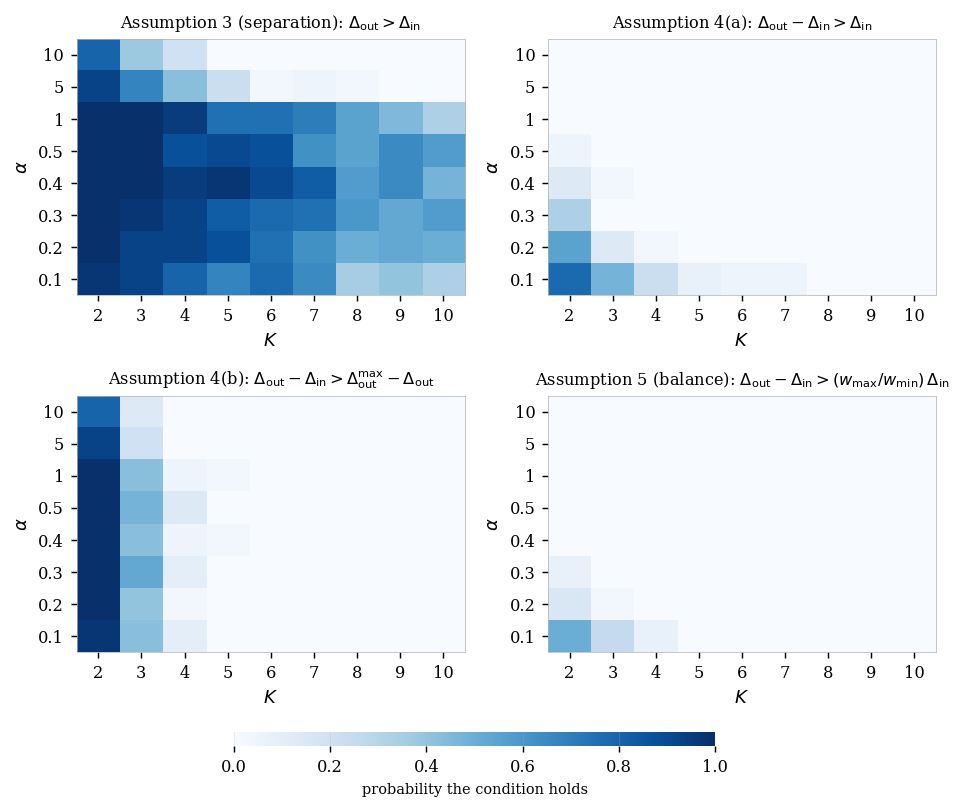

figure written to Figures/assumptions_gamma_margins.pdf


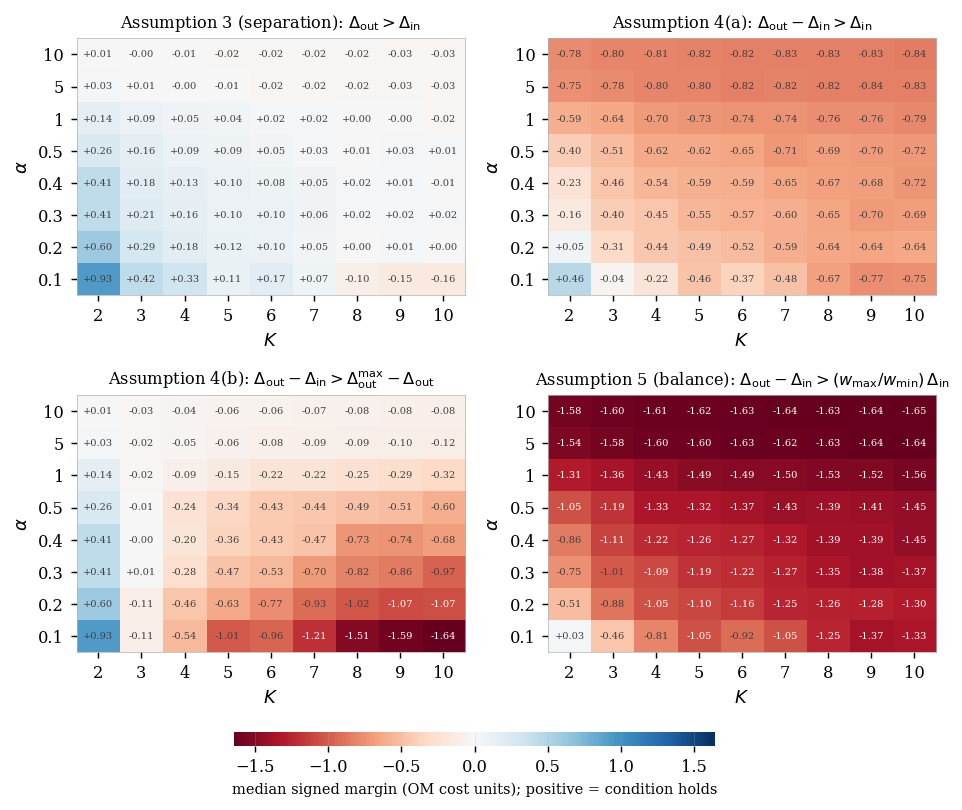

In [6]:
_ = plot_all_conditions(probs, margins, ALPHAS, KS, annotate=False,
                        filename="assumptions_gamma_all")
_ = plot_all_margins(margins, ALPHAS, KS, annotate=True,
                     filename="assumptions_gamma_margins")

figure written to Figures/assumption_separation.pdf


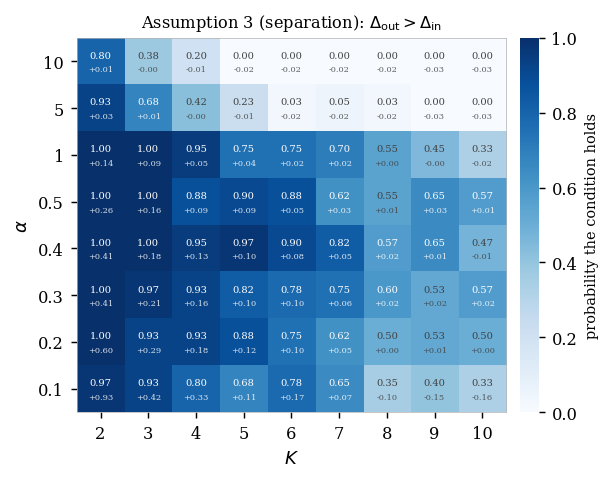

figure written to Figures/assumption_strong_separation_a.pdf


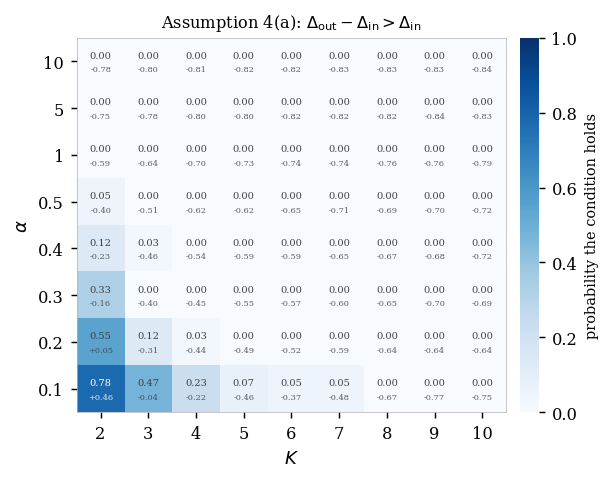

figure written to Figures/assumption_strong_separation_b.pdf


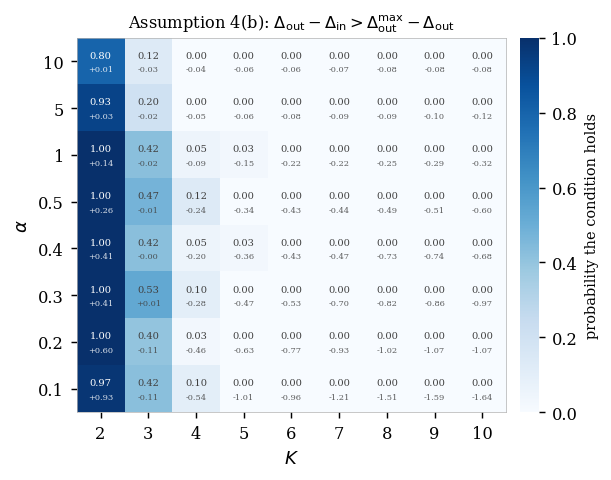

figure written to Figures/assumption_balance.pdf


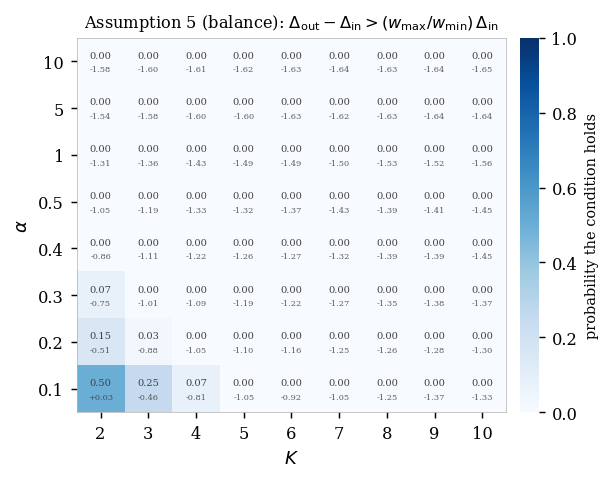

In [7]:
for name in CONDITIONS:
    _ = plot_condition(name, probs, margins, ALPHAS, KS, annotate=True,
                       filename=f"assumption_{name}")

In [12]:
print(margins)



{'separation': array([[ 0.93333333,  0.422     ,  0.32933333,  0.11066667,  0.17      ,
         0.066     , -0.098     , -0.154     , -0.162     ],
       [ 0.59933333,  0.294     ,  0.18333333,  0.11533333,  0.09866667,
         0.04533333,  0.002     ,  0.014     ,  0.00466667],
       [ 0.41333333,  0.20866667,  0.16266667,  0.09733333,  0.098     ,
         0.058     ,  0.02066667,  0.01666667,  0.01933333],
       [ 0.412     ,  0.18466667,  0.13333333,  0.102     ,  0.078     ,
         0.052     ,  0.024     ,  0.01333333, -0.00533333],
       [ 0.25666667,  0.16066667,  0.094     ,  0.08533333,  0.05066667,
         0.02533333,  0.00666667,  0.02533333,  0.014     ],
       [ 0.14333333,  0.09333333,  0.05466667,  0.04066667,  0.02      ,
         0.018     ,  0.002     , -0.00333333, -0.022     ],
       [ 0.02933333,  0.01133333, -0.00266667, -0.00733333, -0.02066667,
        -0.02      , -0.02266667, -0.02533333, -0.03066667],
       [ 0.00866667, -0.004     , -0.00666667, 

### Median $\Delta_{\mathrm{in}}$ and $\Delta_{\mathrm{out}}$

The conditions above are ratios, so it helps to see the two quantities they compare. Both are
bounded by $M = 2$.

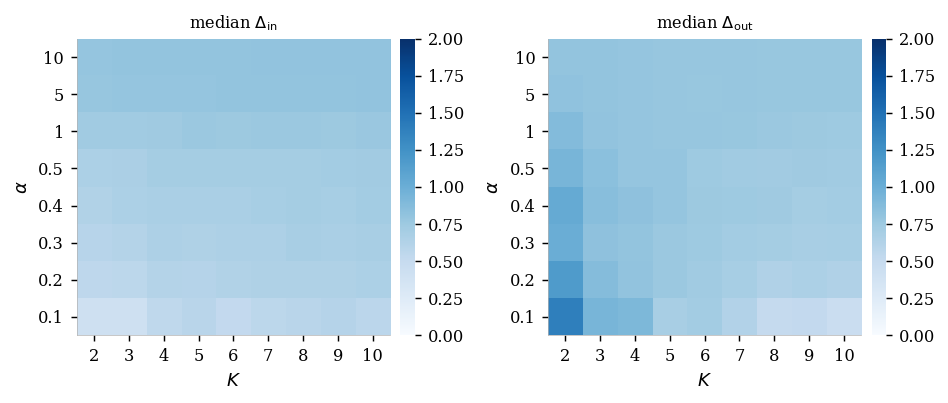

In [8]:
with plt.rc_context(PAPER_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.2))
    for ax, key, lab in zip(axes, ("Delta_in", "Delta_out"),
                            (r"median $\Delta_{\mathrm{in}}$", r"median $\Delta_{\mathrm{out}}$")):
        im = ax.imshow(extra[key], origin="lower", aspect="auto", cmap=SEQUENTIAL_CMAP,
                       vmin=0.0, vmax=2.0)
        ax.set_xticks(range(len(KS)), [str(K) for K in KS])
        ax.set_yticks(range(len(ALPHAS)), [f"{a:g}" for a in ALPHAS])
        ax.set_xlabel(r"$K$")
        ax.set_ylabel(r"$\alpha$")
        ax.set_title(lab, fontsize=9, pad=6)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.4)
            spine.set_color("0.7")
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.outline.set_visible(False)
    fig.tight_layout()
    for ext in ("pdf", "png"):
        fig.savefig(f"Figures/Assumptions/assumptions_gamma_levels.{ext}", bbox_inches="tight")
    plt.show()

### Diagnostic: is the horizon large enough?

A row of the heatmaps is only a statement about $\gamma$ if $n$ is large compared to the mixing
time of the chains, since what is actually computed is $\hat\gamma_n$. The relaxation time
$1/(1-|\lambda_2|)$ of a Dirichlet($\alpha$) kernel explodes as $\alpha \to 0$: the rows become
near-deterministic, the chain gets trapped in a cycle for a very long time, and two realisations of
the *same* component can stay far apart. The bottom rows of the heatmaps should therefore be read
as finite-$n$ statements, not as statements about $\gamma$.

In [9]:
rng_diag = np.random.default_rng(SEED)
print(f"{'alpha':>7}  {'median 1-|lambda_2|':>19}  {'relaxation time':>16}  {'n / relaxation':>14}")
for a in ALPHAS:
    gaps = np.array([spectral_gap(sample_markov_model(D_STATES, 1, float(a), rng_diag)["transitions"])
                     for _ in range(200)])
    g = float(np.median(gaps))
    relax = np.inf if g <= 1e-12 else 1.0 / g
    print(f"{a:>7g}  {g:>19.4f}  {relax:>16.1f}  {N_SEQ / relax:>14.0f}")

  alpha  median 1-|lambda_2|   relaxation time  n / relaxation
    0.1               0.2039               4.9             306
    0.2               0.3646               2.7             547
    0.3               0.4356               2.3             653
    0.4               0.4671               2.1             701
    0.5               0.5094               2.0             764
      1               0.6302               1.6             945
      5               0.8281               1.2            1242
     10               0.8737               1.1            1311
